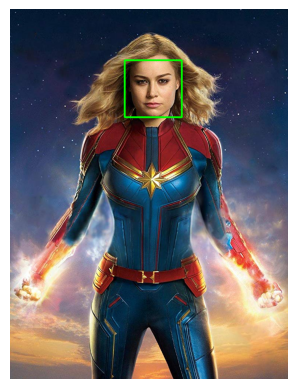

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_path)
def detect_face(img):
    img_copy = img.copy()
    gray_img = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
    face_rects = face_cascade.detectMultiScale(gray_img, scaleFactor=1.2, minNeighbors=8 ,minSize=(80, 80)      )

    for (x, y, w, h) in face_rects:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 3)

    return img_copy

# Read an image file instead of accessing the camera
img = cv2.imread('captin_marvel.jpg')
img_with_detection = detect_face(img)

# Display the image with detected faces
plt.imshow(cv2.cvtColor(img_with_detection, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

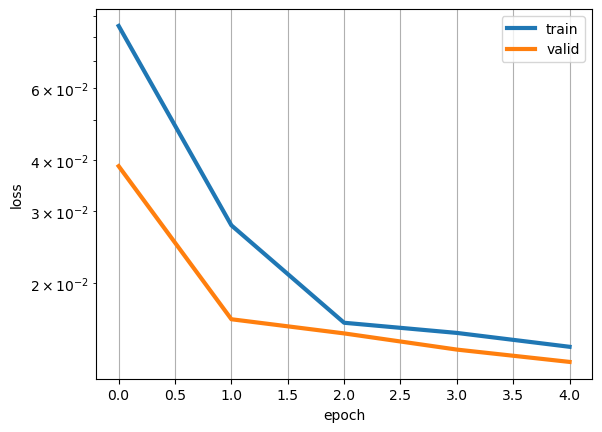

In [2]:
import os
import sys
from datetime import datetime
import numpy as np
import pandas as pd
from pandas import DataFrame
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

FTRAIN = 'data/training.csv'
FTEST = 'data/test.csv'
FLOOKUP = 'data/IdLookupTable.csv'

def load(test=False, cols=None):
    fname = FTEST if test else FTRAIN
    df = pd.read_csv(fname)

    df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

    if cols:
        df = df[list(cols) + ['Image']]

    print(df.count())
    df = df.dropna()

    X = np.vstack(df['Image'].values) / 255.0
    X = X.astype(np.float32)

    if not test:
        y = df[df.columns[:-1]].values
        y = (y - 48) / 48
        X, y = shuffle(X, y, random_state=42)
        y = y.astype(np.float32)
    else:
        y = None

    return X, y

X, y = load()
print("X.shape == {}; X.min == {:.3f}; X.max == {:.3f}".format(X.shape, X.min(), X.max()))
print("y.shape == {}; y.min == {:.3f}; y.max == {:.3f}".format(y.shape, y.min(), y.max()))

X_t = torch.from_numpy(X)    
y_t = torch.from_numpy(y)  

N = X_t.shape[0]
split = int(N * 0.8)
X_tr, y_tr = X_t[:split], y_t[:split]
X_va, y_va = X_t[split:], y_t[split:]

batch_size = 256
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

class MLPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9216, 100),
            nn.ReLU(),
            nn.Linear(100, 30)  
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPRegressor().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, nesterov=True)

def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_cnt  = 0

    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            if train:
                optimizer.zero_grad()

            preds = model(xb)              
            loss = criterion(preds, yb)

            if train:
                loss.backward()
                optimizer.step()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_cnt  += bs

    return total_loss / total_cnt

epochs = 5
train_losses, val_losses = [], []

for ep in range(1, epochs + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader,   train=False)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.6f} | val loss {va_loss:.6f}")

plt.plot(train_losses, linewidth=3, label='train')
plt.plot(val_losses, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.yscale('log')
plt.show()

In [3]:
def predict_keypoints_single_face(model, face_img_bgr):  
    gray = cv2.cvtColor(face_img_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (96, 96)).astype(np.float32) / 255.0
    input_tensor = torch.from_numpy(resized.reshape(1, 1, 96, 96)).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(input_tensor.view(1, -1)).cpu().numpy().reshape(-1)

    
    keypoints = pred * 48 + 48

    vis_img = (resized * 255).astype(np.uint8)  
    vis_img = cv2.cvtColor(vis_img, cv2.COLOR_GRAY2RGB) 

    for i in range(0, len(keypoints), 2):
        x = int(keypoints[i])
        y = int(keypoints[i+1])
        cv2.circle(vis_img, (x, y), 2, (0, 255, 0), -1)


    plt.figure(figsize=(2, 2))
    plt.imshow(vis_img)
    plt.title("PART RESULT")
    plt.axis('off')
    plt.show()
    return keypoints


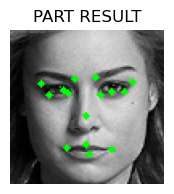

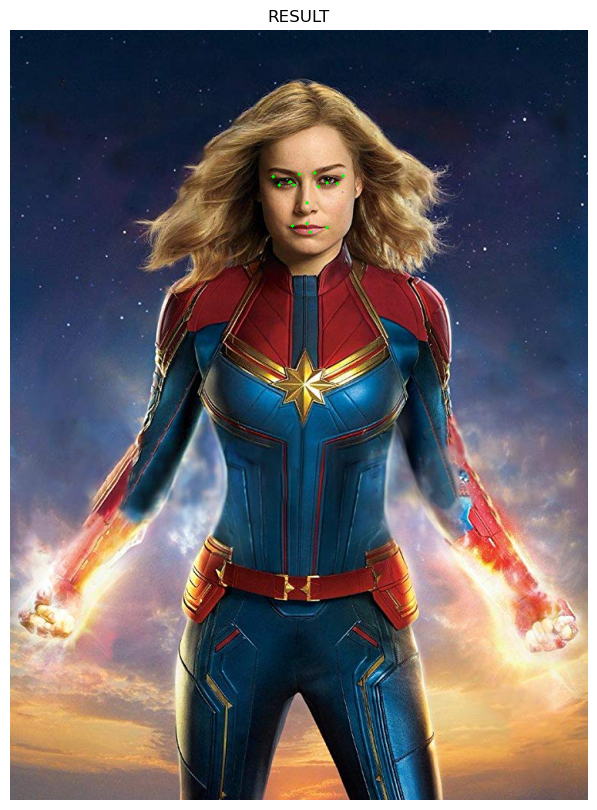

In [4]:
img_bgr = cv2.imread('captin_marvel.jpg')  
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
output_img = img_rgb.copy()


faces = face_cascade.detectMultiScale(img_rgb, scaleFactor=1.2, minNeighbors=5)


for (x, y, w, h) in faces:
    face_roi = img_bgr[y:y+h, x:x+w]

    if face_roi.shape[0] < 96 or face_roi.shape[1] < 96:
        continue  

    keypoints = predict_keypoints_single_face(model, face_roi)


    face_with_kp = face_roi.copy()
    for i in range(0, len(keypoints), 2):
        kp_x = int(keypoints[i] * (w / 96))
        kp_y = int(keypoints[i+1] * (h / 96))
        cv2.circle(face_with_kp, (kp_x, kp_y), 2, (0, 255, 0), -1)


    face_with_kp = cv2.resize(face_with_kp, (w, h))
    output_img[y:y+h, x:x+w] = cv2.cvtColor(face_with_kp, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 10))
plt.imshow(output_img)
plt.axis('off')
plt.title("RESULT")
plt.show()
